# Customer Retention — Churn Prediction
**Dataset:** IBM Telco Customer Churn
**Methodology:** CRISP-DM

---

## CRISP-DM Phases
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

---
## Phase 1 — Business Understanding

### Problem Statement
A telecom company wants to identify customers likely to cancel (churn) so retention teams can intervene proactively. Acquiring a new customer costs 5–7× more than retaining one.

### Business Objective
Predict `Churn Value = 1` with high **recall** — missing a churner is more costly than a false alarm.

### Success Criteria
| Metric | Target |
|--------|--------|
| ROC-AUC | ≥ 0.85 |
| Recall (Churn) | ≥ 0.75 |
| F1-Score (Churn) | ≥ 0.70 |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score
)
import joblib, os

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed — skipping XGB model')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Phase 2 — Data Understanding

In [2]:
# 2.1  Load dataset
df_raw = pd.read_excel('Dataset/Telco_customer_churn.xlsx')
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


In [3]:
# 2.2  Data types
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [4]:
# 2.3  Descriptive statistics
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# 2.4  Missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Missing values:')
print(missing if len(missing) else 'None at face value')
print('\nNon-numeric entries in Total Charges:')
print(df_raw['Total Charges'][pd.to_numeric(df_raw['Total Charges'], errors='coerce').isna()].unique())

Missing values:
Churn Reason    5174
dtype: int64

Non-numeric entries in Total Charges:
[' ']


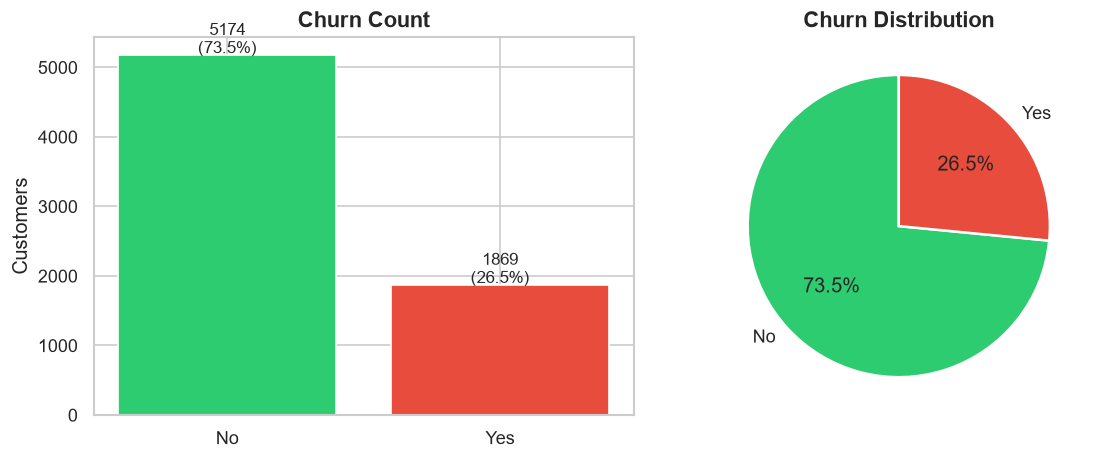

Imbalance ratio (No:Yes): 2.8:1


In [6]:
# 2.5  Target distribution
churn_counts = df_raw['Churn Label'].value_counts()
churn_pct    = df_raw['Churn Label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Customers')
for i, (val, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, val + 30, f'{val}\n({pct:.1f}%)', ha='center', fontsize=10)

axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Churn Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Imbalance ratio (No:Yes): {churn_counts['No']/churn_counts['Yes']:.1f}:1")

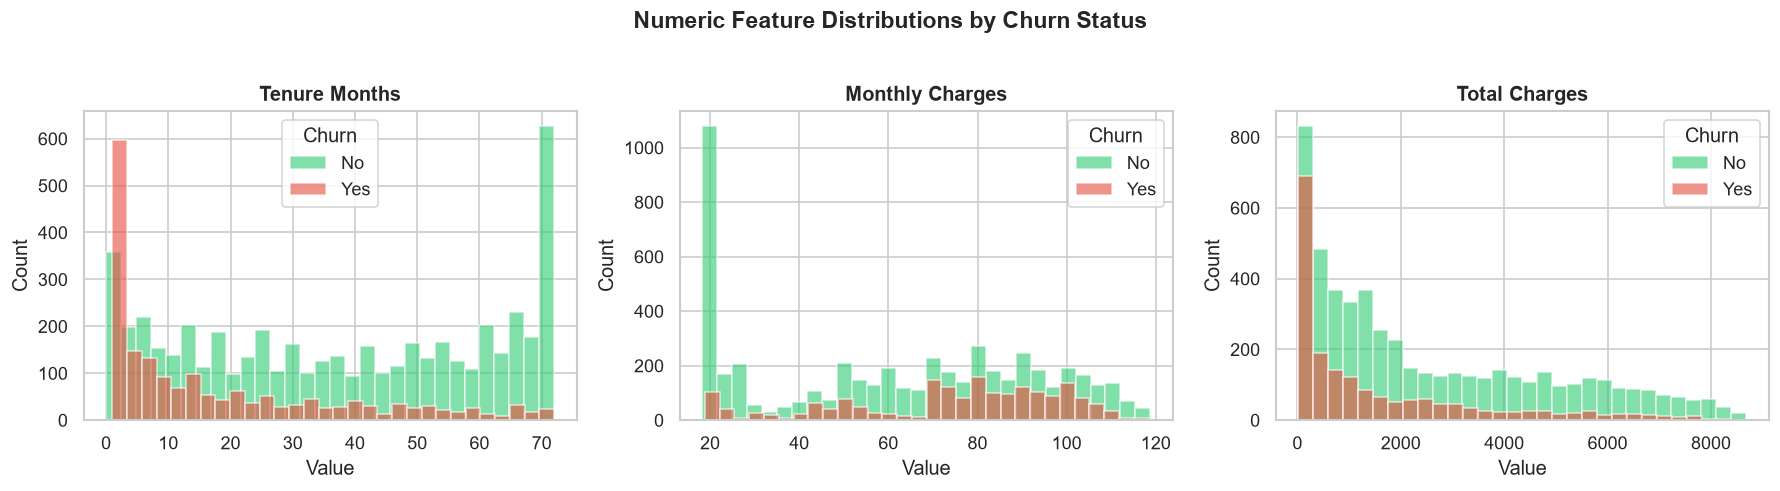

In [7]:
# 2.6  Numeric distributions by churn
df_plot = df_raw.copy()
df_plot['Total Charges'] = pd.to_numeric(df_plot['Total Charges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Tenure Months', 'Monthly Charges', 'Total Charges']):
    for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        ax.hist(df_plot[df_plot['Churn Label'] == label][col].dropna(),
                bins=30, alpha=0.6, color=color, label=label)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.legend(title='Churn')
plt.suptitle('Numeric Feature Distributions by Churn Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

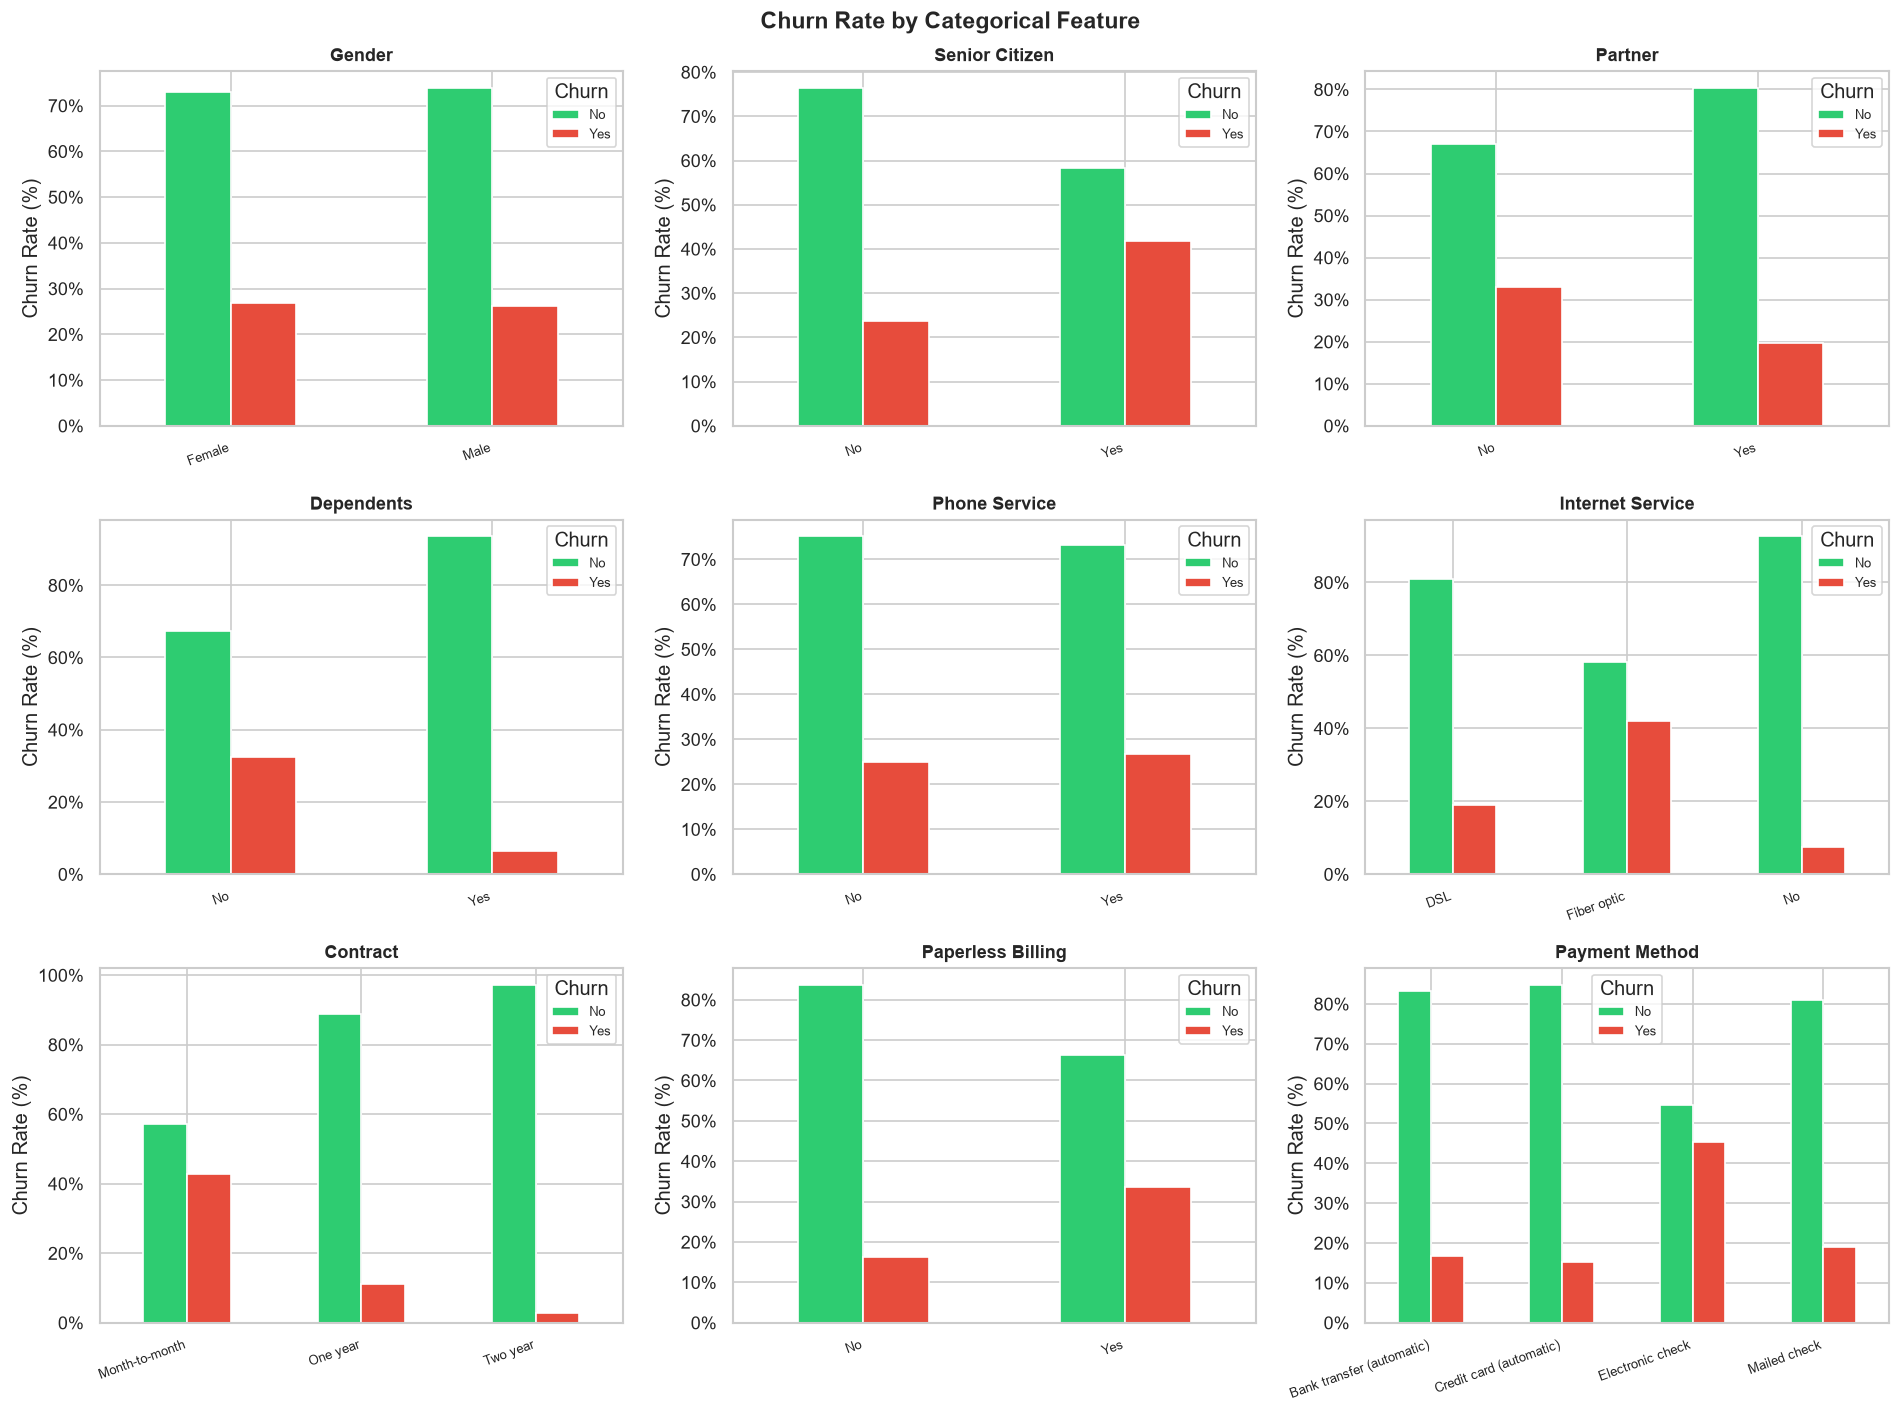

In [8]:
# 2.7  Categorical features vs Churn (churn rate bars)
cat_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
            'Phone Service', 'Internet Service', 'Contract',
            'Paperless Billing', 'Payment Method']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df_raw[col], df_raw['Churn Label'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Churn Rate (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
    ax.legend(title='Churn', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

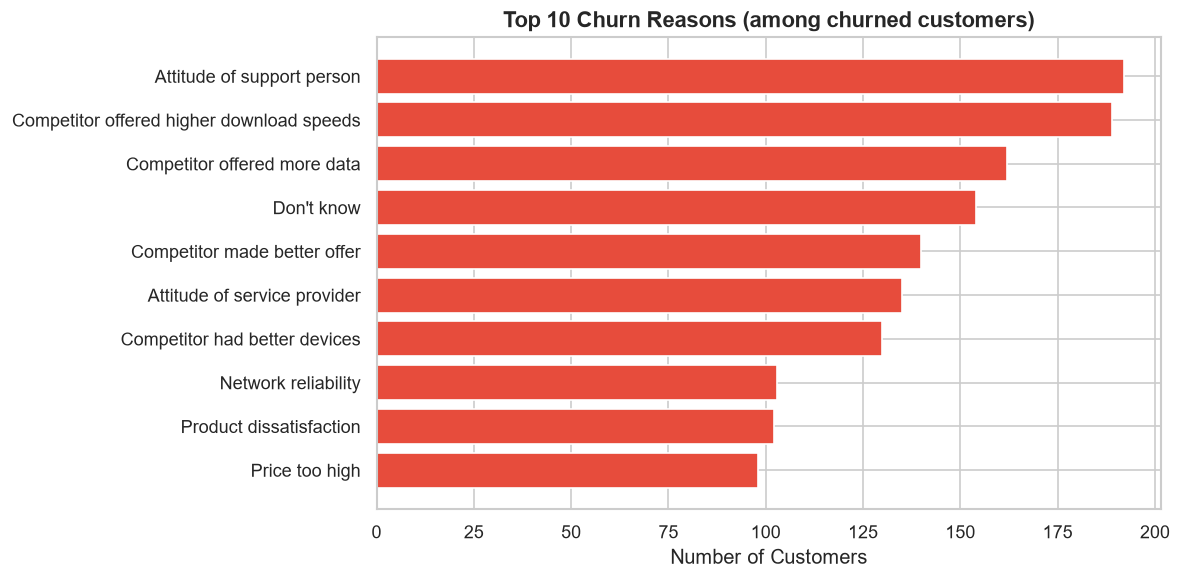

In [9]:
# 2.8  Top 10 churn reasons
churned = df_raw[df_raw['Churn Label'] == 'Yes']
reason_counts = churned['Churn Reason'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(reason_counts.index[::-1], reason_counts.values[::-1],
         color='#e74c3c', edgecolor='white')
plt.xlabel('Number of Customers')
plt.title('Top 10 Churn Reasons (among churned customers)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Phase 3 — Data Preparation

In [10]:
# 3.1  Drop leakage and non-informative columns
# Churn Score  → derived from target (leakage)
# Churn Reason → only known post-churn (leakage)
# Churn Label  → string duplicate of target
# Geography    → all California, zero variance
DROP_COLS = [
    'CustomerID', 'Count', 'Country', 'State', 'City',
    'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
    'Churn Label', 'Churn Score', 'Churn Reason'
]
df = df_raw.drop(columns=DROP_COLS).copy()
print(f'Shape after dropping: {df.shape}')
df.head(3)

Shape after dropping: (7043, 21)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,5372


In [11]:
# 3.2  Fix data types
# Total Charges has blank strings for new customers with Tenure = 0
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
null_tc = df['Total Charges'].isna().sum()
print(f'NaN Total Charges: {null_tc} → imputing with 0 (Tenure = 0 customers)')
df['Total Charges'].fillna(0, inplace=True)

NaN Total Charges: 11 → imputing with 0 (Tenure = 0 customers)


0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: Total Charges, Length: 7043, dtype: float64

In [12]:
# 3.3  Feature engineering
# Average spend per month (divergence from current charge = loyalty signal)
df['Avg Monthly Spend'] = np.where(
    df['Tenure Months'] > 0,
    df['Total Charges'] / df['Tenure Months'],
    df['Monthly Charges']
)

# Ordinal tenure band
df['Tenure Band'] = pd.cut(
    df['Tenure Months'], bins=[0, 12, 24, 48, 72],
    labels=['0-12m', '13-24m', '25-48m', '49-72m'], right=True
)

# Count of add-on services — more services = stickier customer
service_cols = ['Online Security', 'Online Backup', 'Device Protection',
                'Tech Support', 'Streaming TV', 'Streaming Movies']
df['Num Services'] = df[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

print('Engineered: Avg Monthly Spend, Tenure Band, Num Services')
df[['Tenure Months', 'Tenure Band', 'Avg Monthly Spend', 'Num Services']].head()

Engineered: Avg Monthly Spend, Tenure Band, Num Services


,Tenure Months,Tenure Band,Avg Monthly Spend,Num Services
0,2,0-12m,54.075000,2
1,2,0-12m,75.825000,0
2,8,0-12m,102.562500,3
3,28,25-48m,108.787500,4
4,49,49-72m,102.781633,4


In [13]:
# 3.4  Encode categorical features
TARGET = 'Churn Value'
y = df[TARGET].values
X = df.drop(columns=[TARGET, 'CLTV'])  # CLTV excluded — derived business metric

# Binary Yes/No and Male/Female columns
binary_map  = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
               'Phone Service', 'Paperless Billing',
               'Online Security', 'Online Backup', 'Device Protection',
               'Tech Support', 'Streaming TV', 'Streaming Movies']
for col in binary_cols:
    X[col] = X[col].map(binary_map).fillna(0).astype(int)

# Nominal columns — one-hot encode
X = pd.get_dummies(X, columns=['Multiple Lines', 'Internet Service',
                                 'Contract', 'Payment Method'], drop_first=False)

# Ordinal tenure band
X['Tenure Band'] = X['Tenure Band'].map(
    {'0-12m': 0, '13-24m': 1, '25-48m': 2, '49-72m': 3}).fillna(0).astype(int)

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
print(f'Feature matrix shape: {X.shape}')
print(X.columns.tolist())

Feature matrix shape: (7043, 31)
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing', 'Monthly Charges', 'Total Charges', 'Avg Monthly Spend', 'Tenure Band', 'Num Services', 'Multiple Lines_No', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_DSL', 'Internet Service_Fiber optic', 'Internet Service_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'Payment Method_Bank transfer (automatic)', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']


In [14]:
# 3.5  Train / Test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} samples  |  Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test : {X_test.shape[0]} samples  |  Churn rate: {y_test.mean()*100:.1f}%')

Train: 5634 samples  |  Churn rate: 26.5%
Test : 1409 samples  |  Churn rate: 26.5%


In [15]:
# 3.6  Feature scaling (needed for Logistic Regression)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)
print('Scaling complete.')

Scaling complete.


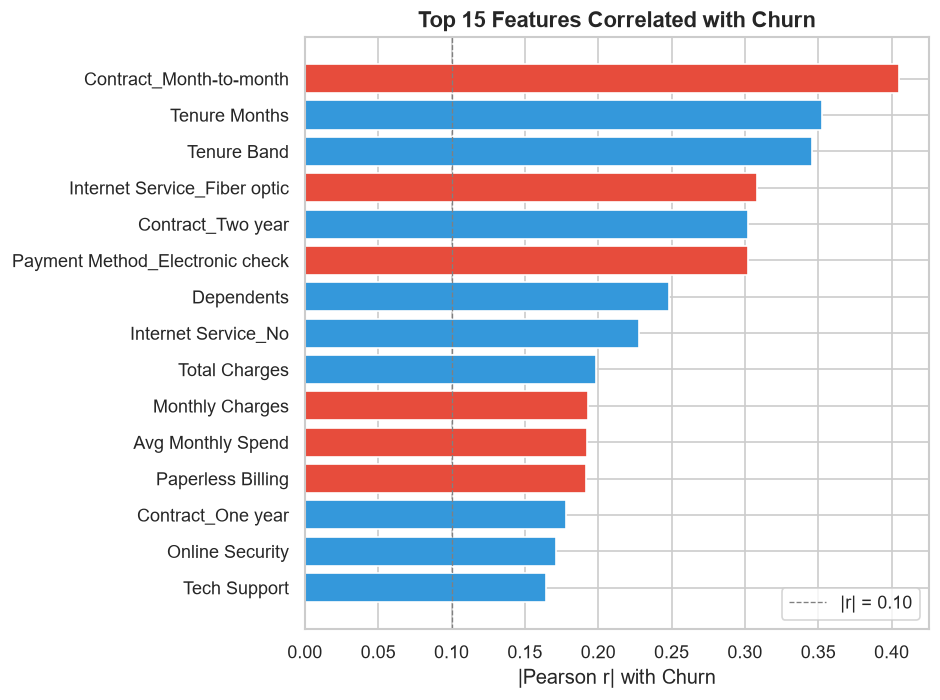

In [16]:
# 3.7  Correlation with target
corr_df   = X.copy()
corr_df['Churn'] = y
corr_vals = corr_df.corr()['Churn'].drop('Churn')
top_corr  = corr_vals.abs().sort_values(ascending=False).head(15)
colors    = ['#e74c3c' if corr_vals[f] > 0 else '#3498db' for f in top_corr.index]

plt.figure(figsize=(8, 6))
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.xlabel('|Pearson r| with Churn')
plt.title('Top 15 Features Correlated with Churn', fontsize=13, fontweight='bold')
plt.axvline(0.1, linestyle='--', color='grey', linewidth=0.8, label='|r| = 0.10')
plt.legend()
plt.tight_layout()
plt.show()

---
## Phase 4 — Modeling

Four classifiers trained with `class_weight='balanced'` to handle the ~73:27 imbalance:

| Model | Notes |
|---|---|
| Logistic Regression | Interpretable baseline |
| Decision Tree | Explainable rule-based splits |
| Random Forest | Robust ensemble, handles interactions |
| Gradient Boosting | High accuracy, iterative error correction |
| XGBoost (optional) | State-of-the-art boosted trees |

In [17]:
# 4.1  Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', C=1.0, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', min_samples_leaf=20, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight='balanced',
        min_samples_leaf=10, n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, min_samples_leaf=10, random_state=RANDOM_STATE)
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0)

print(f'Models defined: {list(models.keys())}')

Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [18]:
# 4.2  5-Fold Stratified Cross-Validation (ROC-AUC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    Xtr    = X_train_sc if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}  AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression        AUC: 0.8584 ± 0.0123
Decision Tree              AUC: 0.8288 ± 0.0089
Random Forest              AUC: 0.8600 ± 0.0101
Gradient Boosting          AUC: 0.8555 ± 0.0067
XGBoost                    AUC: 0.8580 ± 0.0076


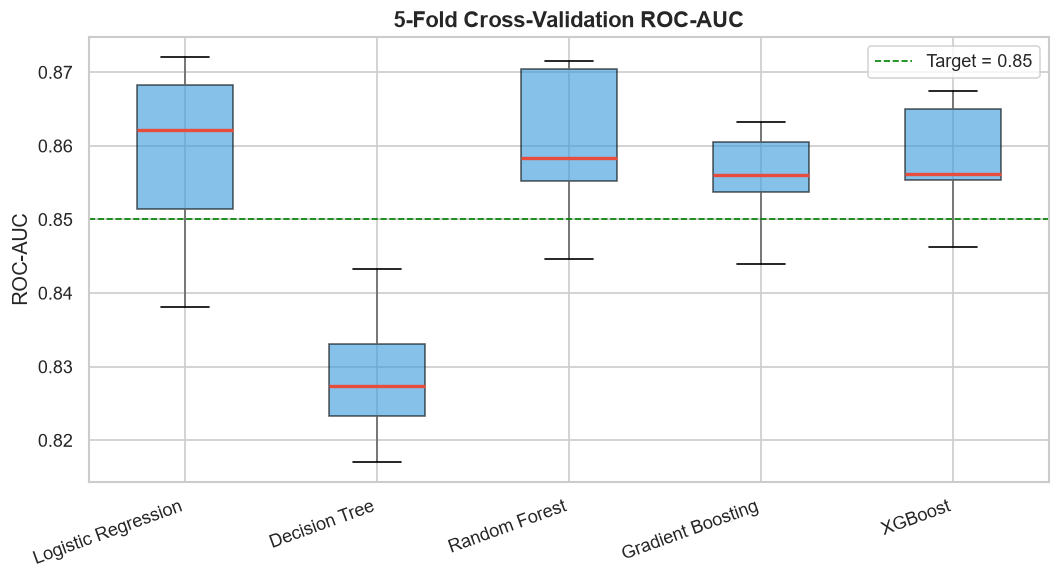

In [19]:
# 4.3  CV results boxplot
cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(9, 5))
cv_df.boxplot(patch_artist=True,
              boxprops=dict(facecolor='#3498db', alpha=0.6),
              medianprops=dict(color='#e74c3c', linewidth=2))
plt.ylabel('ROC-AUC')
plt.title('5-Fold Cross-Validation ROC-AUC', fontsize=13, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.axhline(0.85, linestyle='--', color='green', linewidth=1, label='Target = 0.85')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# 4.4  Fit all models on full training set
fitted_models = {}
for name, model in models.items():
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    model.fit(Xtr, y_train)
    fitted_models[name] = model
    print(f'{name} — trained.')

Logistic Regression — trained.
Decision Tree — trained.
Random Forest — trained.
Gradient Boosting — trained.
XGBoost — trained.


---
## Phase 5 — Evaluation

In [21]:
# 5.1  Test-set metrics for all models
results = []
for name, model in fitted_models.items():
    Xte    = X_test_sc if name == 'Logistic Regression' else X_test
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model').sort_values('ROC-AUC', ascending=False)
results_df.style.background_gradient(cmap='YlGn').format('{:.4f}')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.7679,0.5430,0.7941,0.6450,0.8551
Gradient Boosting,0.7977,0.6413,0.5401,0.5864,0.8522
XGBoost,0.7622,0.5358,0.7807,0.6355,0.8521
Logistic Regression,0.7459,0.5140,0.7861,0.6216,0.8482
Decision Tree,0.7395,0.5060,0.7941,0.6181,0.8243


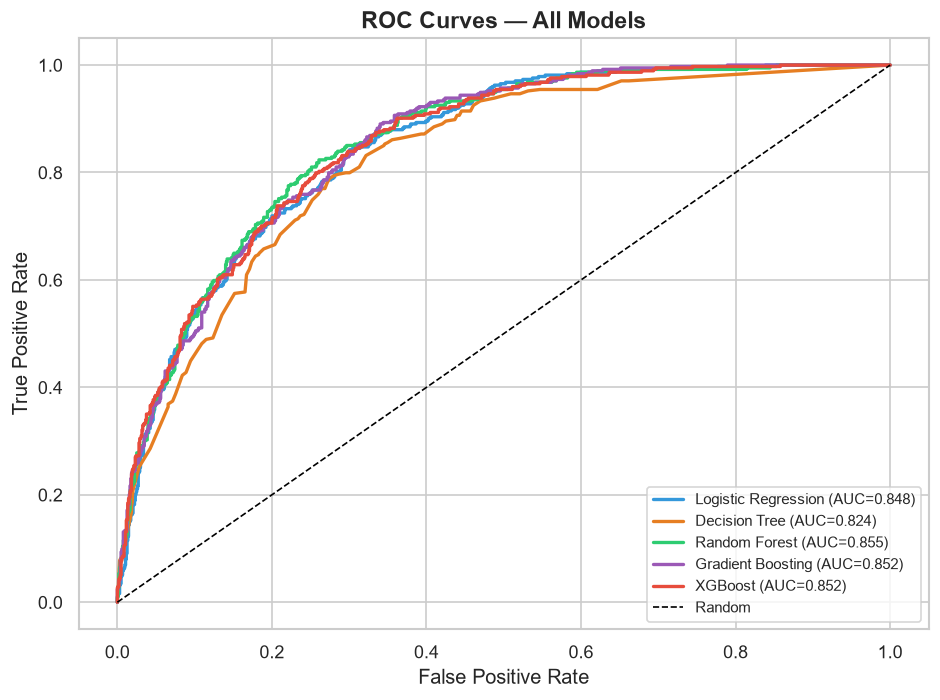

In [22]:
# 5.2  ROC Curves — all models
fig, ax = plt.subplots(figsize=(8, 6))
palette = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c']
for (name, model), color in zip(fitted_models.items(), palette):
    Xte    = X_test_sc if name == 'Logistic Regression' else X_test
    y_prob = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, y_prob):.3f})',
            color=color, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

In [23]:
# 5.3  Select best model & full classification report
auc_scores = {
    name: roc_auc_score(
        y_test,
        model.predict_proba(X_test_sc if name == 'Logistic Regression' else X_test)[:, 1])
    for name, model in fitted_models.items()
}
best_name  = max(auc_scores, key=auc_scores.get)
best_model = fitted_models[best_name]
Xte_best   = X_test_sc if best_name == 'Logistic Regression' else X_test
y_pred_best = best_model.predict(Xte_best)

print(f'Best Model: {best_name}  (AUC = {auc_scores[best_name]:.4f})\n')
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

Best Model: Random Forest  (AUC = 0.8551)

              precision    recall  f1-score   support

    No Churn       0.91      0.76      0.83      1035
       Churn       0.54      0.79      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409



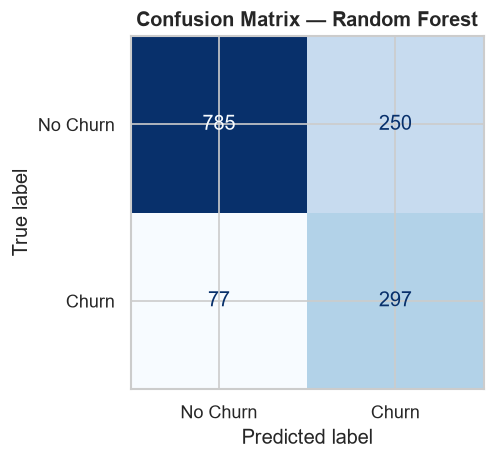

True Positives  (caught churners) : 297
False Negatives (missed churners) : 77
False Positives (false alarms)    : 250
True Negatives  (correct retains) : 785


In [24]:
# 5.4  Confusion matrix — best model
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (caught churners) : {tp}')
print(f'False Negatives (missed churners) : {fn}')
print(f'False Positives (false alarms)    : {fp}')
print(f'True Negatives  (correct retains) : {tn}')

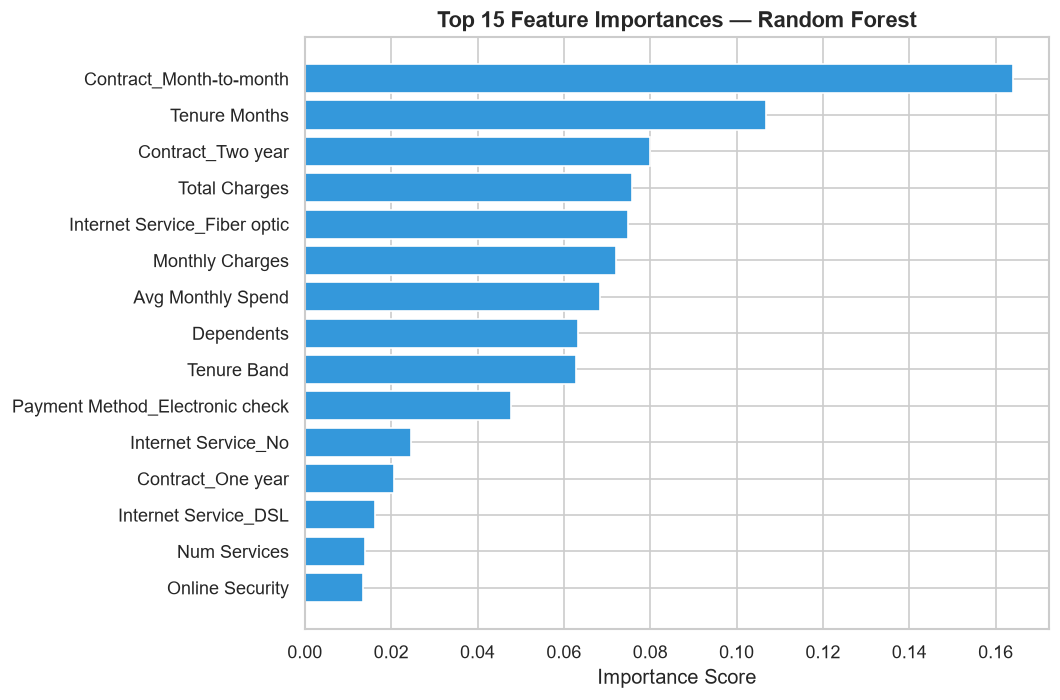

In [25]:
# 5.5  Feature importances — best model
feature_names = X.columns.tolist()
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    feat_imp = (pd.Series(importances, index=feature_names)
                .sort_values(ascending=False).head(15))
    plt.figure(figsize=(9, 6))
    plt.barh(feat_imp.index[::-1], feat_imp.values[::-1], color='#3498db', edgecolor='white')
    plt.xlabel('Importance Score')
    plt.title(f'Top 15 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

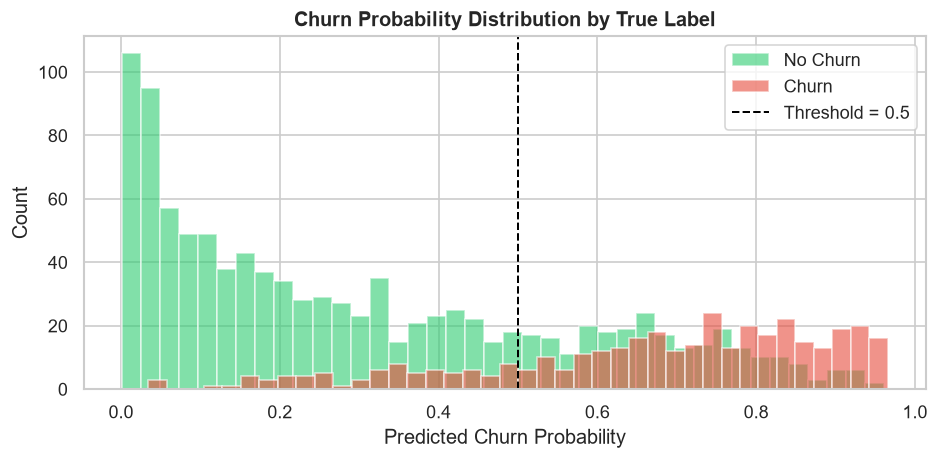

In [26]:
# 5.6  Predicted probability distribution
y_prob_best = best_model.predict_proba(Xte_best)[:, 1]
plt.figure(figsize=(8, 4))
for label, color, lname in [(0, '#2ecc71', 'No Churn'), (1, '#e74c3c', 'Churn')]:
    plt.hist(y_prob_best[y_test == label], bins=40, alpha=0.6, color=color, label=lname)
plt.axvline(0.5, linestyle='--', color='black', linewidth=1.2, label='Threshold = 0.5')
plt.xlabel('Predicted Churn Probability')
plt.ylabel('Count')
plt.title('Churn Probability Distribution by True Label', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout(); plt.show()

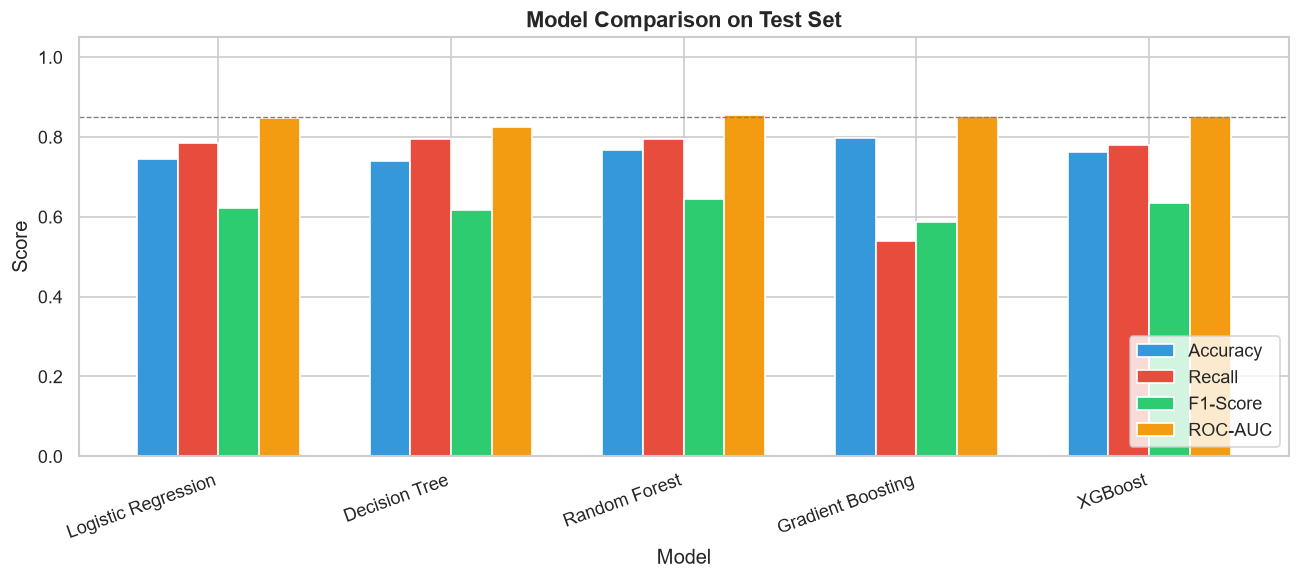

In [27]:
# 5.7  Multi-metric model comparison bar chart
chart_data = []
for name, model in fitted_models.items():
    Xte = X_test_sc if name == 'Logistic Regression' else X_test
    yp  = model.predict(Xte)
    ypr = model.predict_proba(Xte)[:, 1]
    chart_data.append({'Model': name,
                       'Accuracy': accuracy_score(y_test, yp),
                       'Recall':   recall_score(y_test, yp),
                       'F1-Score': f1_score(y_test, yp),
                       'ROC-AUC':  roc_auc_score(y_test, ypr)})

chart_df = pd.DataFrame(chart_data).set_index('Model')
ax = chart_df.plot(kind='bar', figsize=(11, 5), width=0.7,
                   color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], edgecolor='white')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison on Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(0.85, linestyle='--', color='grey', linewidth=0.8)
plt.tight_layout(); plt.show()

---
## Phase 6 — Deployment

In [28]:
# 6.1  Save best model, scaler, and feature list
os.makedirs('models', exist_ok=True)
model_path = f'models/{best_name.replace(" ", "_")}_churn_model.pkl'
joblib.dump(best_model,          model_path)
joblib.dump(scaler,              'models/scaler.pkl')
joblib.dump(X.columns.tolist(),  'models/feature_names.pkl')
print(f'Saved: {model_path}')
print('Saved: models/scaler.pkl  |  models/feature_names.pkl')

Saved: models/Random_Forest_churn_model.pkl
Saved: models/scaler.pkl  |  models/feature_names.pkl


In [29]:
# 6.2  Prediction helper for a single customer
def predict_churn(customer_dict: dict, threshold: float = 0.5) -> dict:
    """Score one customer dict. Returns prediction, probability, and risk tier."""
    _model    = joblib.load(f'models/{best_name.replace(" ", "_")}_churn_model.pkl')
    _scaler   = joblib.load('models/scaler.pkl')
    _features = joblib.load('models/feature_names.pkl')

    row = pd.DataFrame([customer_dict])
    row['Total Charges'] = pd.to_numeric(row.get('Total Charges', [0]), errors='coerce').fillna(0)
    tenure = float(row['Tenure Months'].iloc[0])
    row['Avg Monthly Spend'] = (
        row['Total Charges'] / tenure if tenure > 0 else row['Monthly Charges'])
    row['Tenure Band'] = (
        0 if tenure <= 12 else 1 if tenure <= 24 else 2 if tenure <= 48 else 3)

    svc = ['Online Security','Online Backup','Device Protection',
           'Tech Support','Streaming TV','Streaming Movies']
    row['Num Services'] = sum(row[c].iloc[0] == 'Yes' for c in svc if c in row.columns)

    bmap = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
    for col in ['Gender','Senior Citizen','Partner','Dependents','Phone Service',
                'Paperless Billing','Online Security','Online Backup',
                'Device Protection','Tech Support','Streaming TV','Streaming Movies']:
        if col in row.columns:
            row[col] = row[col].map(bmap).fillna(0).astype(int)

    row = pd.get_dummies(row, columns=['Multiple Lines','Internet Service',
                                        'Contract','Payment Method'], drop_first=False)
    for col in _features:
        if col not in row.columns:
            row[col] = 0
    row = row[_features].apply(pd.to_numeric, errors='coerce').fillna(0)

    if best_name == 'Logistic Regression':
        row = _scaler.transform(row)
    prob = float(_model.predict_proba(row)[0, 1])
    pred = int(prob >= threshold)
    risk = 'HIGH' if prob >= 0.70 else 'MEDIUM' if prob >= 0.40 else 'LOW'
    return {'churn_prediction': pred, 'churn_probability': round(prob, 4), 'risk_level': risk}

print('predict_churn() defined.')

predict_churn() defined.


In [30]:
# 6.3  Example: score two customer profiles
high_risk = {
    'Gender': 'Female', 'Senior Citizen': 'No', 'Partner': 'No', 'Dependents': 'No',
    'Tenure Months': 2, 'Phone Service': 'Yes', 'Multiple Lines': 'No',
    'Internet Service': 'Fiber optic', 'Online Security': 'No', 'Online Backup': 'No',
    'Device Protection': 'No', 'Tech Support': 'No', 'Streaming TV': 'No',
    'Streaming Movies': 'No', 'Contract': 'Month-to-month',
    'Paperless Billing': 'Yes', 'Payment Method': 'Electronic check',
    'Monthly Charges': 70.70, 'Total Charges': 151.65
}
low_risk = {
    'Gender': 'Male', 'Senior Citizen': 'No', 'Partner': 'Yes', 'Dependents': 'Yes',
    'Tenure Months': 60, 'Phone Service': 'Yes', 'Multiple Lines': 'Yes',
    'Internet Service': 'DSL', 'Online Security': 'Yes', 'Online Backup': 'Yes',
    'Device Protection': 'Yes', 'Tech Support': 'Yes', 'Streaming TV': 'Yes',
    'Streaming Movies': 'Yes', 'Contract': 'Two year',
    'Paperless Billing': 'No', 'Payment Method': 'Bank transfer (automatic)',
    'Monthly Charges': 95.00, 'Total Charges': 5700.00
}
for label, customer in [('High-risk profile', high_risk), ('Low-risk  profile', low_risk)]:
    r = predict_churn(customer)
    print(f'{label}: Prediction={r["churn_prediction"]} '
          f'({"CHURN" if r["churn_prediction"] else "STAY"}), '
          f'Probability={r["churn_probability"]*100:.1f}%, Risk={r["risk_level"]}')

High-risk profile: Prediction=1 (CHURN), Probability=81.9%, Risk=HIGH
Low-risk  profile: Prediction=0 (STAY), Probability=3.0%, Risk=LOW


---
## Summary

| CRISP-DM Phase | Key Outcome |
|---|---|
| **Business Understanding** | Maximize recall on churners; AUC ≥ 0.85 |
| **Data Understanding** | 7,043 customers; ~26.5% churn; drivers: month-to-month contract, fiber optic, short tenure |
| **Data Preparation** | Removed leakage cols; engineered Tenure Band, Avg Monthly Spend, Num Services; OHE nominals |
| **Modeling** | 4–5 classifiers with balanced class weights; 5-fold stratified CV |
| **Evaluation** | Best model by ROC-AUC; confusion matrix, classification report, feature importances |
| **Deployment** | Model + scaler saved via joblib; `predict_churn()` for real-time single-customer scoring |